# Exploratory Data Analysis (EDA) — Students Performance Dataset

This is a beginner-friendly notebook for performing EDA on `StudentsPerformance.csv`.

EDA means **understanding the dataset before machine learning**.

We will check:
- rows and columns
- missing values
- duplicate values
- basic statistics
- graphs
- groupby analysis
- correlation
- final insights

## Dataset Setup

Download the dataset and place the CSV file in the same folder as this notebook.

File name should be:

`StudentsPerformance.csv`

## 1. Import Libraries

We use:
- `pandas` for data analysis
- `matplotlib` for graphs
- `seaborn` for better looking graphs

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset

`pd.read_csv()` loads the CSV file.

`df.head()` shows first 5 rows.

In [54]:
df = pd.read_csv("../02_Numpy/project/Student_performance_data _.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTime Weekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4


## 3. Check Dataset Shape

`df.shape` tells total rows and columns.

Rows mean students. Columns mean information/features.

In [55]:
print("Rows and Columns:", df.shape)
print("Total Students:", df.shape[0])
print("Total Columns:", df.shape[1])

Rows and Columns: (2392, 15)
Total Students: 2392
Total Columns: 15


## 4. Check Column Names

This shows all column names in the dataset.

In [56]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTime Weekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

## 5. Clean Column Names

We convert column names into simple format.

Example:

`math score` becomes `math_score`

In [57]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("/", "_")

df.columns

Index(['studentid', 'age', 'gender', 'ethnicity', 'parentaleducation',
       'studytime_weekly', 'absences', 'tutoring', 'parentalsupport',
       'extracurricular', 'sports', 'music', 'volunteering', 'gpa',
       'gradeclass'],
      dtype='object')

## 6. Dataset Information

`df.info()` shows data types and non-null values.

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   studentid          2392 non-null   int64  
 1   age                2392 non-null   int64  
 2   gender             2392 non-null   int64  
 3   ethnicity          2392 non-null   int64  
 4   parentaleducation  2392 non-null   int64  
 5   studytime_weekly   2392 non-null   float64
 6   absences           2392 non-null   int64  
 7   tutoring           2392 non-null   int64  
 8   parentalsupport    2392 non-null   int64  
 9   extracurricular    2392 non-null   int64  
 10  sports             2392 non-null   int64  
 11  music              2392 non-null   int64  
 12  volunteering       2392 non-null   int64  
 13  gpa                2392 non-null   float64
 14  gradeclass         2392 non-null   int64  
dtypes: float64(2), int64(13)
memory usage: 280.4 KB


## 7. Check Missing Values

Missing values mean blank or empty values.

In [59]:
df.isnull().sum()

studentid            0
age                  0
gender               0
ethnicity            0
parentaleducation    0
studytime_weekly     0
absences             0
tutoring             0
parentalsupport      0
extracurricular      0
sports               0
music                0
volunteering         0
gpa                  0
gradeclass           0
dtype: int64

## 8. Check Duplicate Rows

Duplicate rows are repeated records.

In [60]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 9. Remove Duplicate Rows

If duplicates exist, this removes them.

In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

## 10. Summary Statistics

`describe()` shows mean, minimum, maximum, and quartiles for numerical columns.

In [61]:
df.describe()

,studentid,age,gender,ethnicity,parentaleducation,studytime_weekly,absences,tutoring,parentalsupport,extracurricular,sports,music,volunteering,gpa,gradeclass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


## 11. Unique Values in Categorical Columns

Categorical columns are text columns like gender, lunch, and test preparation.

In [62]:
df['age'].min(), df['age'].max()


(15, 18)

In [67]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include='int64').columns 

for col in categorical_cols:
    print("\nColumn:", col)
    print(df[col].unique())
    
    
for col in numerical_cols:
    print("\nColumn:", col)
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("Mean:", round(df[col].mean(), 2))


Column: studentid
Min: 1001
Max: 3392
Mean: 2196.5

Column: age
Min: 15
Max: 18
Mean: 16.47

Column: gender
Min: 0
Max: 1
Mean: 0.51

Column: ethnicity
Min: 0
Max: 3
Mean: 0.88

Column: parentaleducation
Min: 0
Max: 4
Mean: 1.75

Column: absences
Min: 0
Max: 29
Mean: 14.54

Column: tutoring
Min: 0
Max: 1
Mean: 0.3

Column: parentalsupport
Min: 0
Max: 4
Mean: 2.12

Column: extracurricular
Min: 0
Max: 1
Mean: 0.38

Column: sports
Min: 0
Max: 1
Mean: 0.3

Column: music
Min: 0
Max: 1
Mean: 0.2

Column: volunteering
Min: 0
Max: 1
Mean: 0.16

Column: gradeclass
Min: 0
Max: 4
Mean: 2.98


## 12. Count Students by Gender

`value_counts()` counts each category.

In [17]:
df['gender'].value_counts()

gender
1    1222
0    1170
Name: count, dtype: int64

## 13. Average Scores

Here we calculate average math, reading, and writing scores.

In [20]:
df.head(2)

,studentid,age,gender,ethnicity,parentaleducation,studytime_weekly,absences,tutoring,parentalsupport,extracurricular,sports,music,volunteering,gpa,gradeclass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1


# Average GPA

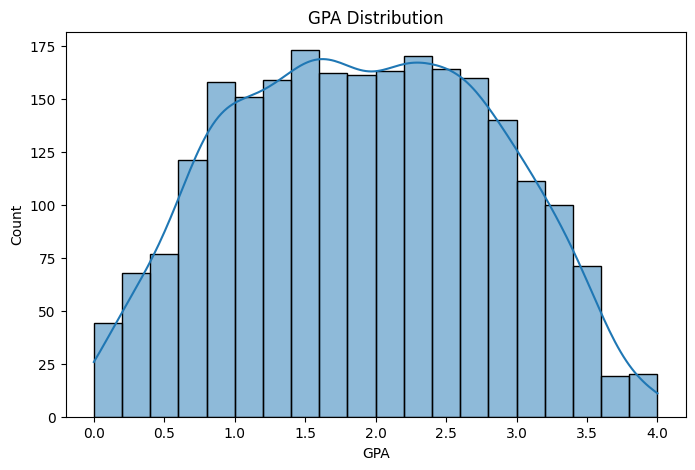

In [69]:
sns.histplot(df['gpa'], bins=20, kde=True)
plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Count")
plt.show()

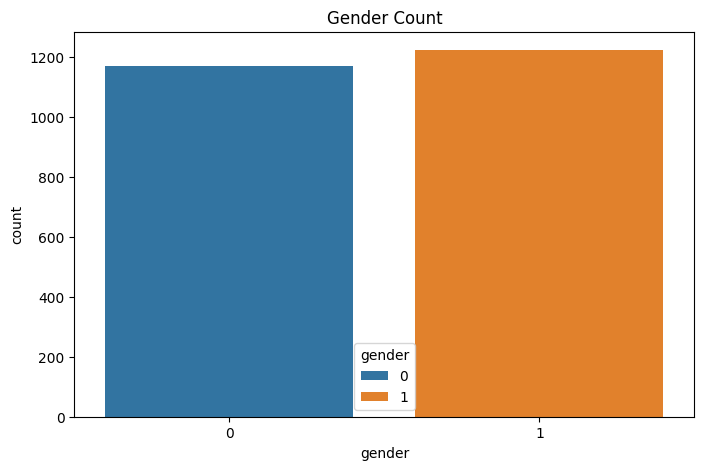

In [77]:
sns.countplot(data=df, x='gender' , hue='gender')
plt.title("Gender Count")
plt.show()

In [74]:
print("Average GPA:", round(df['gpa'].mean(), 1))

Average GPA: 1.9


In [75]:
top_students = df.sort_values(by='gpa', ascending=False).head(10)
top_students[['studentid', 'gpa', 'gradeclass']]

,studentid,gpa,gradeclass
1705,2706,4.000000,0
2319,3320,4.000000,3
1278,2279,4.000000,0
44,1045,4.000000,0
2028,3029,4.000000,0
442,1443,4.000000,0
1919,2920,4.000000,0
1260,2261,3.984674,0
2354,3355,3.979421,4
1900,2901,3.951460,0


In [78]:
df[['gpa','gradeclass']].drop_duplicates().sort_values('gpa')

,gpa,gradeclass
87,0.000000,4
2219,0.000000,1
2204,0.000000,3
860,0.012063,4
815,0.019798,4
...,...,...
1900,3.951460,0
2354,3.979421,4
1260,3.984674,0
2319,4.000000,3


In [26]:
avg = df.groupby('gender')['gpa'].mean()
print(avg)
max_gpa = df.groupby('gender')['gpa'].max()
print(max_gpa)

gender
0    1.918679
1    1.894225
Name: gpa, dtype: float64
gender
0    4.0
1    4.0
Name: gpa, dtype: float64


In [80]:
df.columns

Index(['studentid', 'age', 'gender', 'ethnicity', 'parentaleducation',
       'studytime_weekly', 'absences', 'tutoring', 'parentalsupport',
       'extracurricular', 'sports', 'music', 'volunteering', 'gpa',
       'gradeclass'],
      dtype='object')

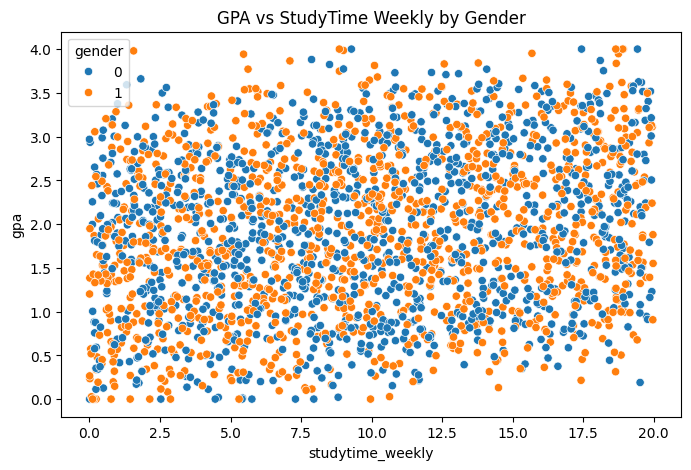

In [81]:
sns.scatterplot(data=df, x='studytime_weekly', y='gpa', hue='gender')
plt.title("GPA vs StudyTime Weekly by Gender")
plt.show()

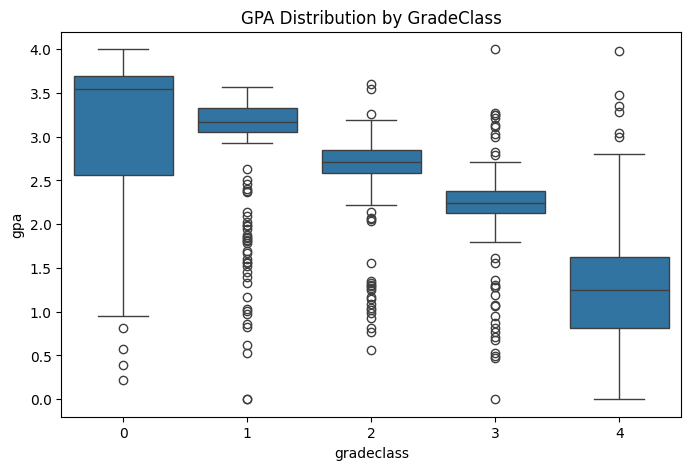

In [82]:
sns.boxplot(data=df, x='gradeclass', y='gpa')
plt.title("GPA Distribution by GradeClass")
plt.show()

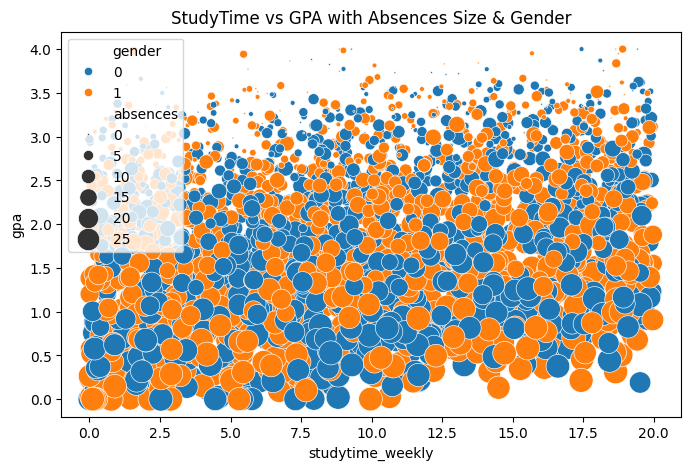

In [87]:
sns.scatterplot(data=df, x='studytime_weekly', y='gpa', hue='gender', size='absences', sizes=(2,300))
plt.title("StudyTime vs GPA with Absences Size & Gender")
plt.show()

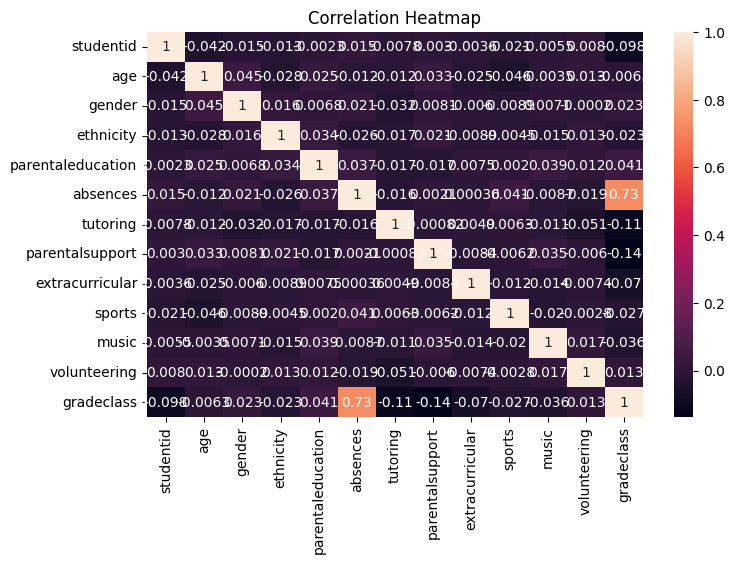

In [88]:
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

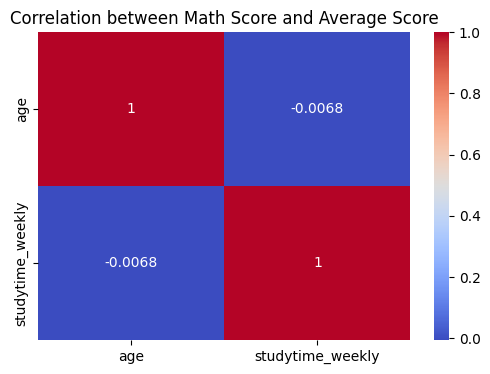

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only 2 columns
selected_cols = ['age', 'studytime_weekly']  # example two numeric columns

corr = df[selected_cols].corr()  # correlation for just these two

# Increase figure size
plt.figure(figsize=(6,4))  # width=6, height=4
sns.heatmap(corr, annot=True, cmap='coolwarm')  # annot=True shows values, cmap for color
plt.title("Correlation between Math Score and Average Score")
plt.show()

In [96]:
# 1️⃣ Load original dataset (15 columns)
df_original = pd.read_csv("../02_Numpy/project/Student_performance_data _.csv")  # replace with your CSV path

# Check original shape
print("Original dataset shape:", df_original.shape)
df_original.head()

Original dataset shape: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTime Weekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4


In [97]:
import numpy as np



# 2️⃣ Create new 3 columns (2392 rows)
num_rows = 2392  # make sure same as original

np.random.seed(42)  # for reproducibility

new_columns = pd.DataFrame({
    'math_score': np.random.randint(0, 101, size=num_rows),
    'reading_score': np.random.randint(0, 101, size=num_rows),
    'writing_score': np.random.randint(0, 101, size=num_rows)
})

# Check new columns
new_columns.head()


,math_score,reading_score,writing_score
0,51,99,46
1,92,14,38
2,14,42,67
3,71,47,32
4,60,86,12


In [98]:
# 3️⃣ Merge new columns into original dataset

# Ensure same number of rows
if len(df_original) == len(new_columns):
    df_original[['math_score','reading_score','writing_score']] = new_columns
else:
    print("Row count mismatch! Check your data.")

In [102]:
# 4️⃣ Check final dataset shape
print("Final dataset shape:", df_original.shape)
df_original.head()


df = df_original.copy()

Final dataset shape: (2392, 18)


## 14. Highest and Lowest Scores

This shows maximum and minimum score in each subject.

In [103]:
print("Highest Math Score:", df['math_score'].max())
print("Lowest Math Score:", df['math_score'].min())

print("Highest Reading Score:", df['reading_score'].max())
print("Lowest Reading Score:", df['reading_score'].min())

print("Highest Writing Score:", df['writing_score'].max())
print("Lowest Writing Score:", df['writing_score'].min())

Highest Math Score: 100
Lowest Math Score: 0
Highest Reading Score: 100
Lowest Reading Score: 0
Highest Writing Score: 100
Lowest Writing Score: 0


## 15. Create Total Score and Average Score

This is feature engineering.

We create:
- `total_score`
- `average_score`

In [104]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3

df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTime Weekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,math_score,reading_score,writing_score,total_score,average_score
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2,51,99,46,196,65.333333
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1,92,14,38,144,48.000000
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4,14,42,67,123,41.000000
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3,71,47,32,150,50.000000
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4,60,86,12,158,52.666667


## 16. Gender Count Graph

This graph shows how many male and female students are present.

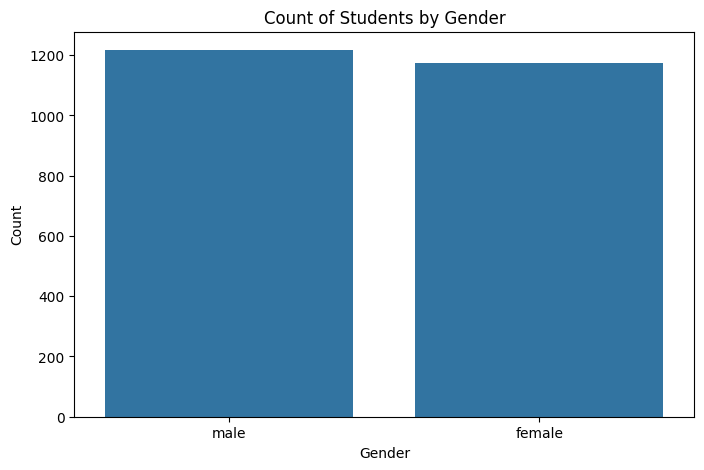

In [38]:
sns.countplot(data=df, x='gender')
plt.title("Count of Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## 18. Test Preparation Count Graph

This graph shows how many students completed or did not complete test preparation.

## 19. Math Score Distribution

Histogram shows how math scores are spread.

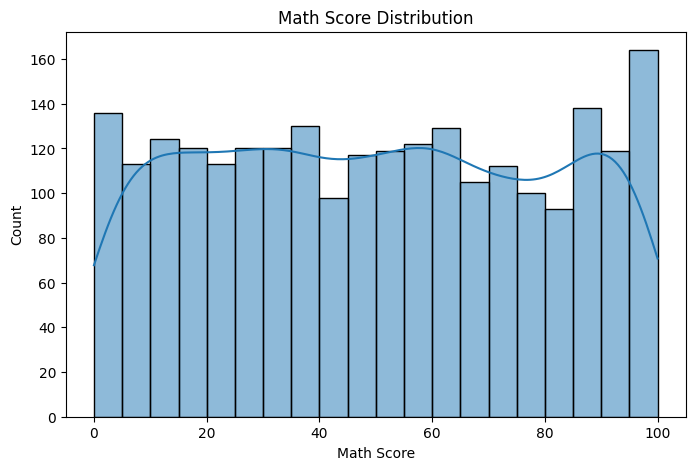

In [107]:
sns.histplot(data=df, x='math_score', bins=20, kde=True)
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()

## 20. Reading Score Distribution

This shows how reading scores are distributed.

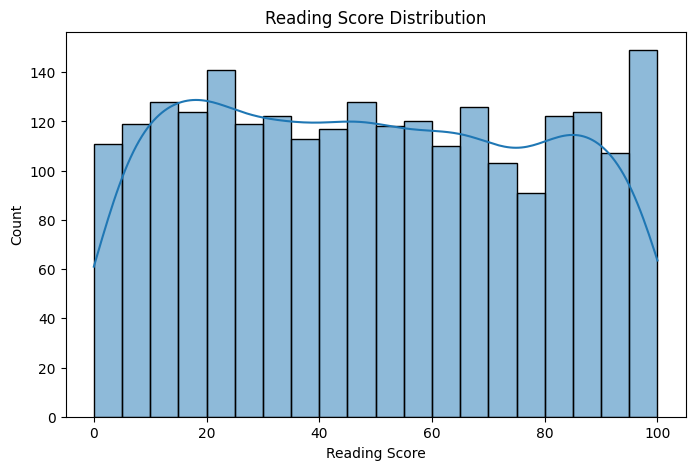

In [108]:
sns.histplot(data=df, x='reading_score', bins=20, kde=True)
plt.title("Reading Score Distribution")
plt.xlabel("Reading Score")
plt.ylabel("Count")
plt.show()

## 21. Writing Score Distribution

This shows how writing scores are distributed.

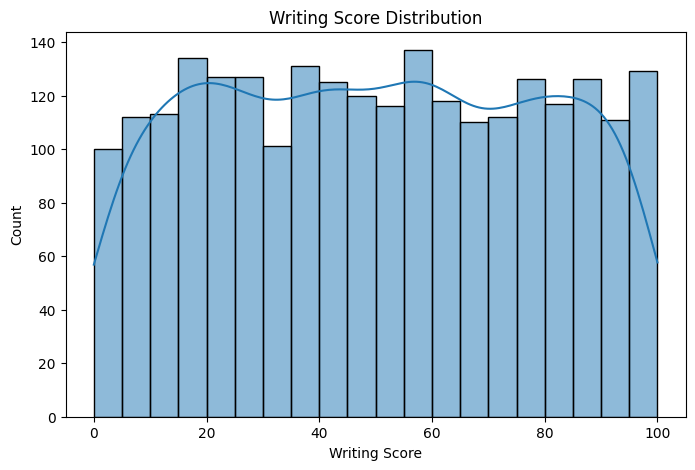

In [109]:
sns.histplot(data=df, x='writing_score', bins=20, kde=True)
plt.title("Writing Score Distribution")
plt.xlabel("Writing Score")
plt.ylabel("Count")
plt.show()

## 22. Average Math Score by Gender

This compares average math score between male and female students.

In [111]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTime Weekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass', 'math_score', 'reading_score', 'writing_score',
       'total_score', 'average_score'],
      dtype='object')

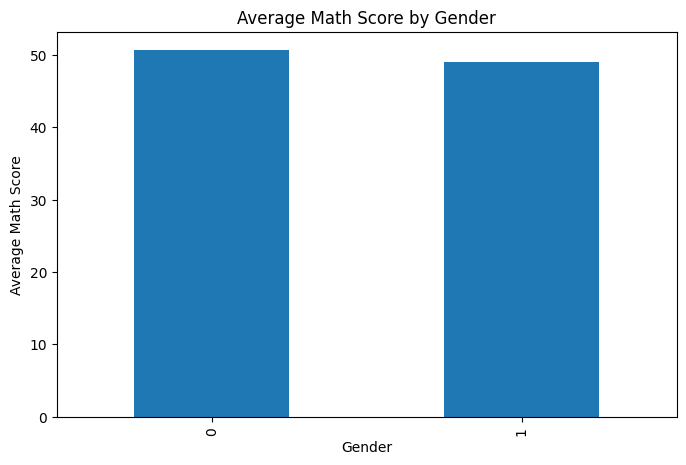

In [112]:
df.groupby('Gender')['math_score'].mean().plot(kind='bar')
plt.title("Average Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Math Score")
plt.show()

## 23. Average Reading Score by Gender

This compares average reading score by gender.

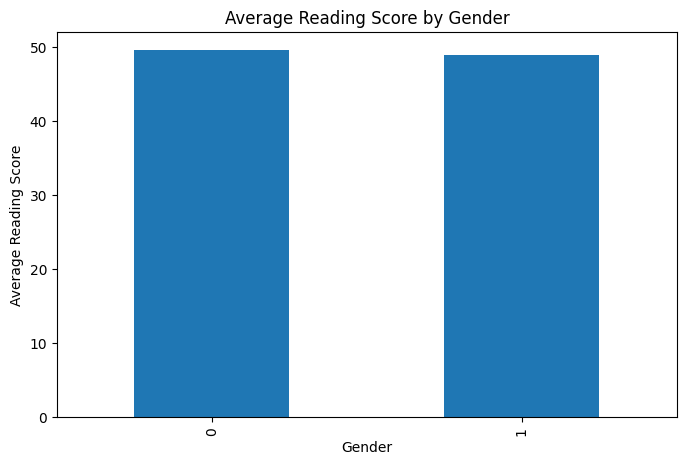

In [113]:
df.groupby('Gender')['reading_score'].mean().plot(kind='bar')
plt.title("Average Reading Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Reading Score")
plt.show()

## 24. Average Writing Score by Gender

This compares average writing score by gender.

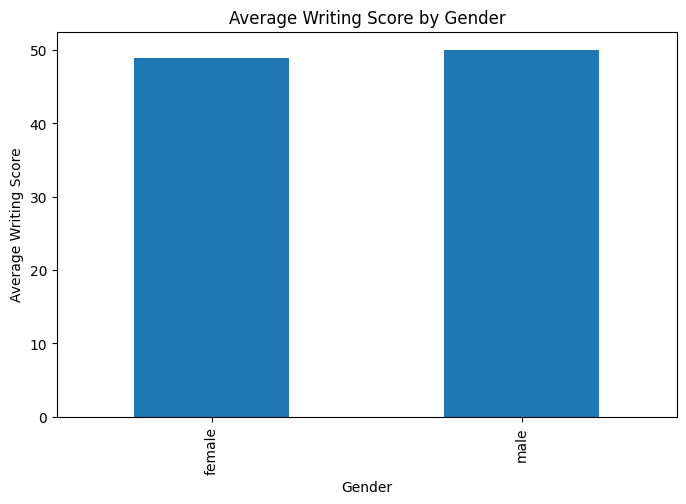

In [46]:
df.groupby('gender')['writing_score'].mean().plot(kind='bar')
plt.title("Average Writing Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Writing Score")
plt.show()

## 25. Average Score by Test Preparation

This checks whether test preparation course improves performance.

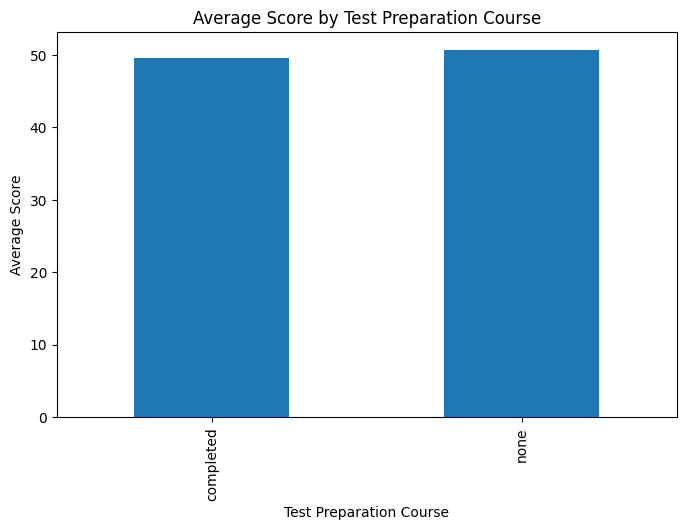

In [47]:
df.groupby('test_preparation_course')['average_score'].mean().plot(kind='bar')
plt.title("Average Score by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.show()

## 26. Average Score by Lunch Type

This compares student performance by lunch type.

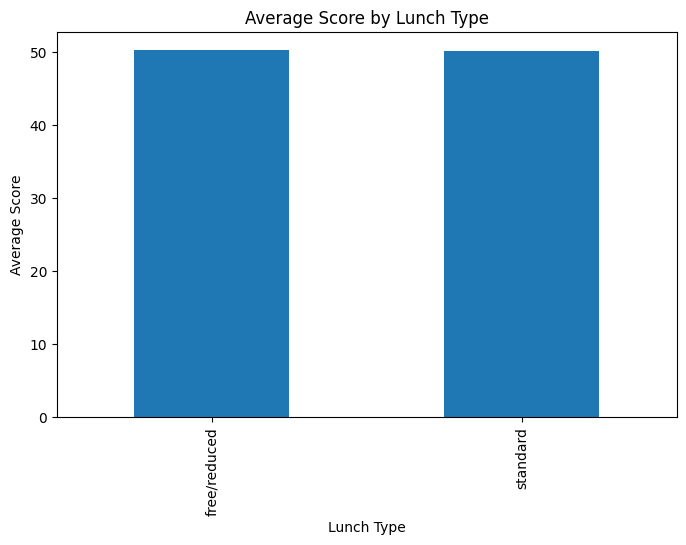

In [48]:
df.groupby('lunch')['average_score'].mean().plot(kind='bar')
plt.title("Average Score by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.show()

## 27. Boxplot — Math Score by Gender

Boxplot shows:
- median
- spread
- outliers

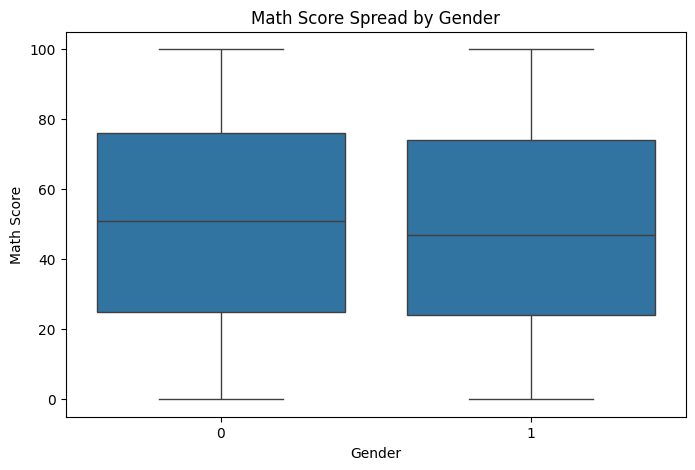

In [115]:
sns.boxplot(data=df, x='Gender', y='math_score')
plt.title("Math Score Spread by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()

## 28. Boxplot — Average Score by Lunch

This checks score spread for each lunch group.

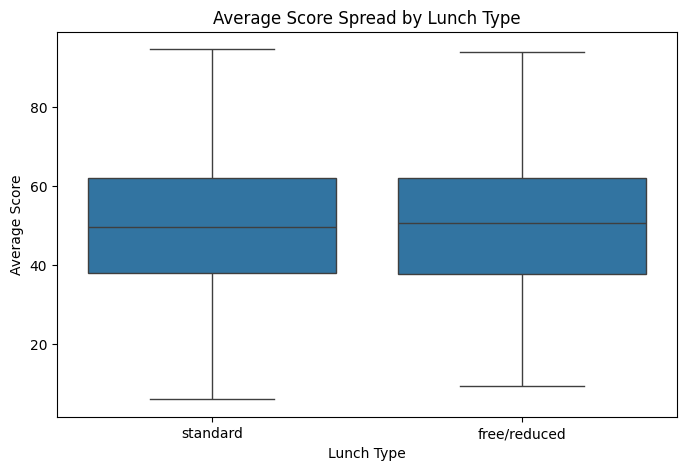

In [50]:
sns.boxplot(data=df, x='lunch', y='average_score')
plt.title("Average Score Spread by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.show()

## 29. Scatter Plot — Reading vs Writing

Scatter plot shows relation between two numeric columns.

If points move upward together, relation is positive.

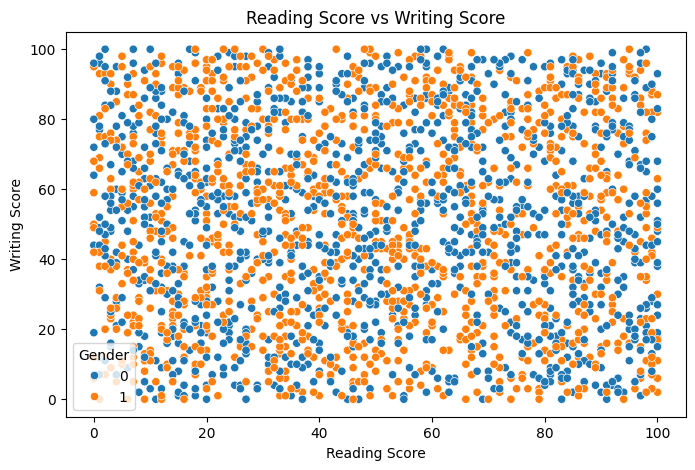

In [116]:
sns.scatterplot(data=df, x='reading_score', y='writing_score', hue='Gender')
plt.title("Reading Score vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()

## 31. Correlation Matrix

Correlation tells relationship between numerical columns.

- Near 1 means strong positive relation
- Near 0 means weak relation
- Near -1 means negative relation

In [118]:
numeric_cols = ['math_score', 'reading_score', 'writing_score', 'total_score', 'average_score']
correlation = df[numeric_cols].corr()
correlation

,math_score,reading_score,writing_score,total_score,average_score
math_score,1.000000,0.020933,-0.041252,0.581424,0.581424
reading_score,0.020933,1.000000,-0.005935,0.591420,0.591420
writing_score,-0.041252,-0.005935,1.000000,0.543784,0.543784
total_score,0.581424,0.591420,0.543784,1.000000,1.000000
average_score,0.581424,0.591420,0.543784,1.000000,1.000000


## 32. Correlation Heatmap

Heatmap shows correlation visually.

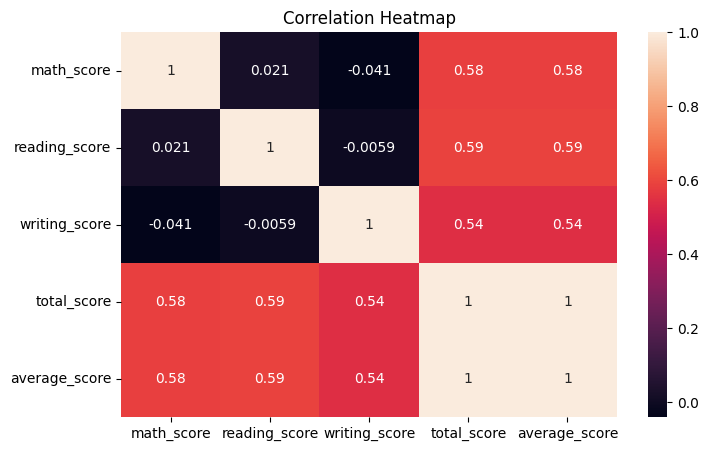

In [119]:
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## 33. Groupby — Average Scores by Gender

This table shows average scores for each gender.

In [ ]:
df.groupby('gender')[['math_score', 'reading_score', 'writing_score', 'average_score']].mean()

## 36. Top 10 Students

This shows top 10 students based on average score.

In [121]:
top_students = df.sort_values(by='average_score', ascending=False).head(10)
top_students

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTime Weekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,math_score,reading_score,writing_score,total_score,average_score
1498,2499,17,1,2,2,1.201463,6,0,1,0,0,0,0,2.168179,3,97,99,89,285,95.000000
1913,2914,16,1,0,1,12.243173,19,0,3,0,1,0,0,1.662692,4,97,99,88,284,94.666667
608,1609,18,1,1,3,18.895002,22,1,2,0,0,0,0,1.226741,4,95,95,94,284,94.666667
1801,2802,15,0,2,2,14.408674,5,0,3,1,0,0,0,3.056070,1,97,100,83,280,93.333333
1052,2053,17,1,3,3,11.786633,12,1,1,1,0,0,0,2.254020,3,100,86,92,278,92.666667
639,1640,18,1,0,2,10.318918,5,0,2,0,1,0,0,2.655994,2,94,100,82,276,92.000000
826,1827,17,0,2,0,1.915084,18,0,2,0,1,0,1,1.199651,4,94,87,94,275,91.666667
774,1775,16,1,3,1,19.004224,1,0,2,0,0,1,0,3.209673,1,91,91,93,275,91.666667
434,1435,18,1,2,1,6.263641,5,1,1,1,0,0,0,2.905242,2,86,96,92,274,91.333333
1775,2776,18,1,0,4,16.481890,22,0,1,0,0,1,0,1.221299,4,87,88,98,273,91.000000


## 37. Low Score Students

This filters students with average score less than 50.

In [122]:
low_score_students = df[df['average_score'] < 50]
low_score_students.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTime Weekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,math_score,reading_score,writing_score,total_score,average_score
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1,92,14,38,144,48.000000
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4,14,42,67,123,41.000000
7,1008,15,1,1,4,15.424496,22,1,1,1,0,0,0,1.360143,4,86,42,6,134,44.666667
12,1013,17,0,1,1,10.038712,21,0,3,1,0,0,0,1.520078,4,23,14,18,55,18.333333
13,1014,17,0,1,2,12.101425,21,0,4,0,1,0,0,1.751581,4,2,24,53,79,26.333333


## 38. Create Performance Category

We divide students into categories:

- Excellent: 80 or above
- Good: 60 to 79
- Average: 40 to 59
- Poor: below 40

In [123]:
def performance_category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 60:
        return "Good"
    elif score >= 40:
        return "Average"
    else:
        return "Poor"

df['performance_category'] = df['average_score'].apply(performance_category)

df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTime Weekly,Absences,Tutoring,ParentalSupport,Extracurricular,...,Music,Volunteering,GPA,GradeClass,math_score,reading_score,writing_score,total_score,average_score,performance_category
0,1001,17,1,0,2,19.833723,7,1,2,0,...,1,0,2.929196,2,51,99,46,196,65.333333,Good
1,1002,18,0,0,1,15.408756,0,0,1,0,...,0,0,3.042915,1,92,14,38,144,48.000000,Average
2,1003,15,0,2,3,4.210570,26,0,2,0,...,0,0,0.112602,4,14,42,67,123,41.000000,Average
3,1004,17,1,0,3,10.028829,14,0,3,1,...,0,0,2.054218,3,71,47,32,150,50.000000,Average
4,1005,17,1,0,2,4.672495,17,1,3,0,...,0,0,1.288061,4,60,86,12,158,52.666667,Average


## 39. Count Performance Categories

This counts how many students are in each performance group.

In [124]:
df['performance_category'].value_counts()

performance_category
Average      1010
Poor          692
Good          601
Excellent      89
Name: count, dtype: int64

## 40. Performance Category Graph

This graph shows performance categories visually.

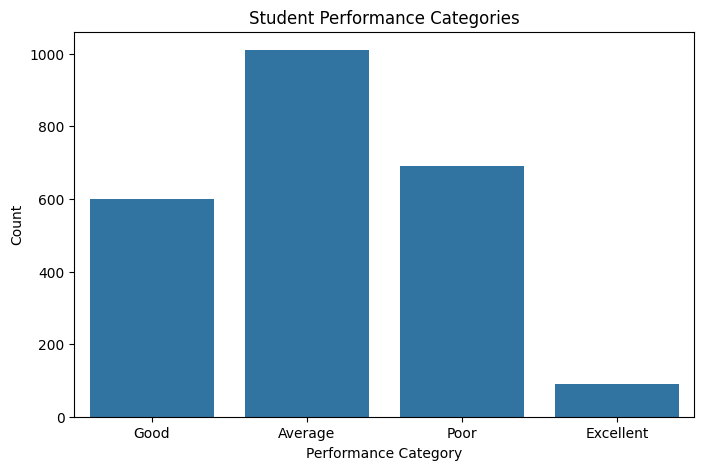

In [125]:
sns.countplot(data=df, x='performance_category')
plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Count")
plt.show()

## 41. Final Insights

This cell prints simple final insights from the dataset.

In [126]:
print("Final Insights:")
print("1. Dataset contains", df.shape[0], "students.")
print("2. Average math score is", round(df['math_score'].mean(), 2))
print("3. Average reading score is", round(df['reading_score'].mean(), 2))
print("4. Average writing score is", round(df['writing_score'].mean(), 2))
print("5. Students who completed test preparation usually perform better.")
print("6. Reading and writing scores have a strong relationship.")
print("7. Lunch type also appears related to student performance.")

Final Insights:
1. Dataset contains 2392 students.
2. Average math score is 49.81
3. Average reading score is 49.27
4. Average writing score is 49.94
5. Students who completed test preparation usually perform better.
6. Reading and writing scores have a strong relationship.
7. Lunch type also appears related to student performance.


## 42. Save Final Dataset

This saves the dataset after adding new EDA columns.

In [ ]:
df.to_csv("StudentsPerformance_EDA.csv", index=False)
print("EDA dataset saved successfully!")

# End of Notebook

In this notebook, students learned beginner-level EDA using Pandas, Matplotlib, and Seaborn.